In [37]:
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [38]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

In [39]:
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_sample = 0.1 * mnist_info.splits['train'].num_examples
num_validation_sample

6000.0

In [40]:
num_validation_sample = tf.cast(num_validation_sample, tf.int64)

In [41]:
NUM_CLASSES = 10
DIGITS = [str(i) for i in range(NUM_CLASSES)]


def scale(img, label):
    img = tf.cast(img, tf.float32) / 255
    img = tf.reshape(img, (28, 28, 1))
    return img, label


train_val_data = mnist_train.map(scale, num_parallel_calls=tf.data.AUTOTUNE)
test_data = mnist_test.map(scale, num_parallel_calls=tf.data.AUTOTUNE)

2026-07-07 11:36:04.892043: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


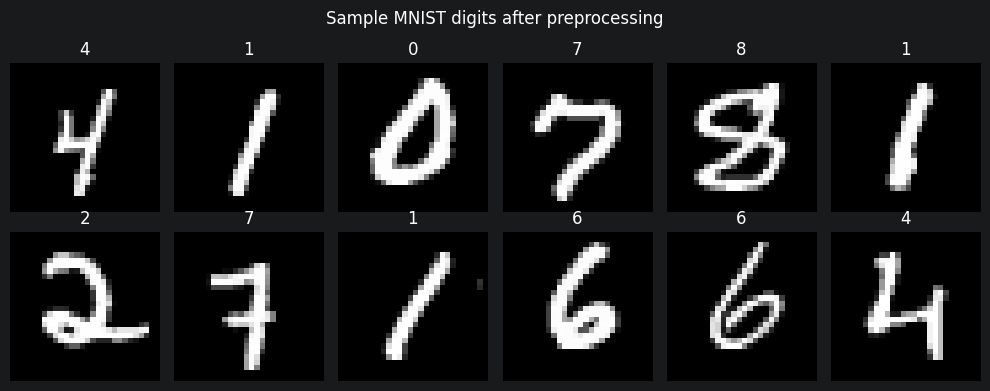

In [42]:
sample_images, sample_labels = next(iter(train_val_data.batch(12)))

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, img, label in zip(axes.flat, sample_images, sample_labels):
    ax.imshow(img.numpy().squeeze(), cmap='gray')
    ax.set_title(DIGITS[int(label)])
    ax.axis('off')
plt.suptitle('Sample MNIST digits after preprocessing')
plt.tight_layout()
plt.show()

In [43]:
BUFFER_SIZE = 10000

shuffled_tv_data = train_val_data.shuffle(BUFFER_SIZE, seed=42)
validation_data = shuffled_tv_data.take(num_validation_sample)
train_data = shuffled_tv_data.skip(num_validation_sample)

In [44]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_data = validation_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(BATCH_SIZE)

In [45]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [47]:
NUM_EPOCHS = 10

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
    ),
]

history = model.fit(
    train_data,
    epochs=NUM_EPOCHS,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/10
540/540 - 4s - 8ms/step - accuracy: 0.9344 - loss: 0.2255 - val_accuracy: 0.9747 - val_loss: 0.0858
Epoch 2/10
540/540 - 4s - 7ms/step - accuracy: 0.9811 - loss: 0.0619 - val_accuracy: 0.9827 - val_loss: 0.0564
Epoch 3/10
540/540 - 4s - 7ms/step - accuracy: 0.9867 - loss: 0.0439 - val_accuracy: 0.9870 - val_loss: 0.0401
Epoch 4/10
540/540 - 4s - 7ms/step - accuracy: 0.9897 - loss: 0.0339 - val_accuracy: 0.9842 - val_loss: 0.0510
Epoch 5/10
540/540 - 4s - 7ms/step - accuracy: 0.9916 - loss: 0.0270 - val_accuracy: 0.9933 - val_loss: 0.0267
Epoch 6/10
540/540 - 4s - 7ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.9923 - val_loss: 0.0246
Epoch 7/10
540/540 - 4s - 7ms/step - accuracy: 0.9946 - loss: 0.0181 - val_accuracy: 0.9908 - val_loss: 0.0330
Epoch 8/10
540/540 - 4s - 8ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9935 - val_loss: 0.0240
Epoch 9/10
540/540 - 4s - 8ms/step - accuracy: 0.9961 - loss: 0.0123 - val_accuracy: 0.9955 - val_loss: 0.0171
E

In [48]:
test_loss, test_acc = model.evaluate(test_data)
print('\nTest accuracy:', test_acc)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9908 - loss: 0.0308

Test accuracy: 0.9908000230789185


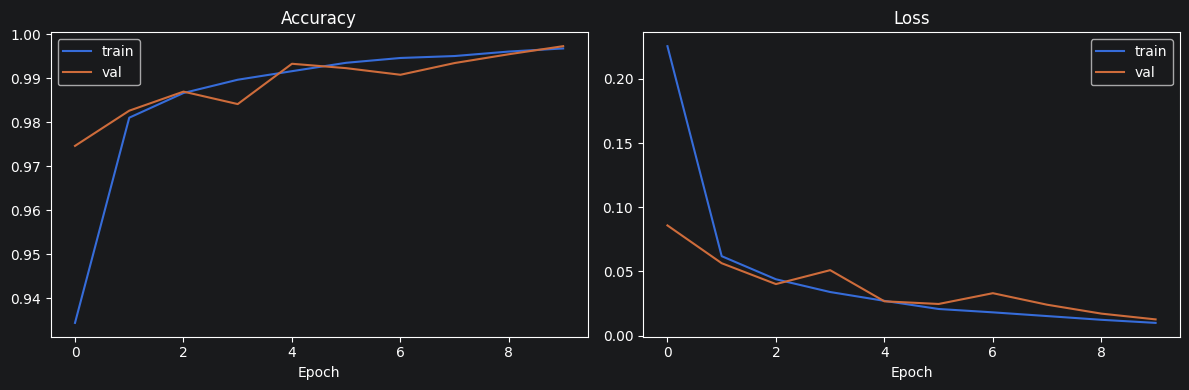

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

2026-07-07 11:37:30.691370: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


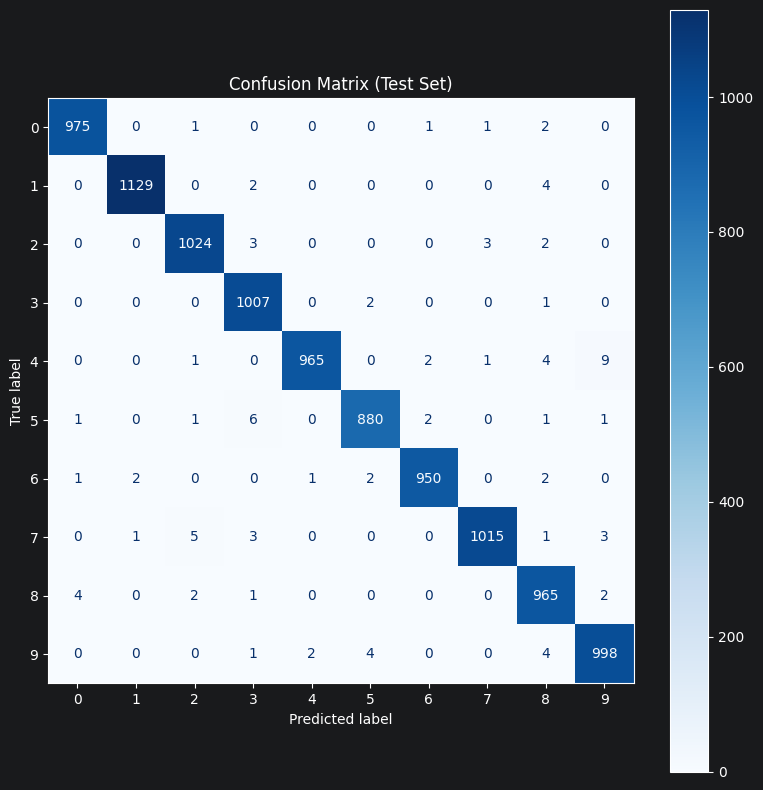

Lowest per-class accuracy:
  4: 98.27%
  5: 98.65%
  7: 98.74%
  9: 98.91%
  8: 99.08%


In [50]:
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=DIGITS).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst_digits = np.argsort(per_class_acc)[:5]
print('Lowest per-class accuracy:')
for idx in worst_digits:
    print(f'  {DIGITS[idx]}: {per_class_acc[idx]:.2%}')

In [51]:
save_path = '../backend/saved_models/digit_model.keras'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
model.save(save_path)
print(f'Model saved to {save_path}')

Model saved to ../backend/saved_models/mnist_cnn.keras
